## Open the Tutorial in your Google Colab!

<a target="_blank" href="https://colab.research.google.com/github/amirhszd/ML4RS_fall2025/blob/main/gee/gee_tutorial_forstudents.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Introduction to Google Earth Engine

Google Earth Engine is a cloud-based platform for geospatial analysis, enabling users to process large-scale datasets using Google's infrastructure. It offers multiple interfaces for interaction:

- [Explorer](https://explorer.earthengine.google.com/)
- [Code Editor](https://code.earthengine.google.com/)
- [JavaScript API](https://github.com/google/earthengine-api/tree/master/javascript)
- [Python API](https://github.com/google/earthengine-api/tree/master/python)

## Installing Google Earth Engine

Use the following command to install Google Earth Engine (GEE) in your environment. It may already be pre-installed.

In [2]:
!pip install earthengine-api


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [11]:
pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 18.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.1/568.1 kB 23.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 50.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [geemap]17/18 [geemap]r]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Authenticating to Earth Engine

To access Google Earth Engine (GEE), first sign up at [GEE Signup](https://signup.earthengine.google.com/).

Authenticate yourself with Google Cloud to gain access to storage and other resources. Run the following code, which will open an authentication page in your browser.

If this is your first time using GEE, you’ll need to create a new project. In the final step, you may also need to register for GEE.

- Select **Unpaid** → **Organization**
- After completing the process, click **Generate Token**
- Copy and paste the token into the output field below.

![authentication](https://github.com/amirhszd/ML4RS_fall2025/blob/main/gee/aut.png?raw=1)

In [4]:
!earthengine authenticate --force

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://accounts.google.com/o/oauth2/auth?client_id=517222506229-vsmmajv00ul0bs7p89v5m89qs8eb9359.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fearthengine+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdevstorage.full_control&redirect_uri=http%3A%2F%2Flocalhost%3A8085&response_type=code&code_challenge=zR-mE-oGH_WI_lnzS-msux0ud8qGGG_26uqi9cUn2t4&code_challenge_method=S256

Waiting for successful authorization from web browser ...

Successfully saved authorization token.


#### Importing and Initializing Earth Engine

Once authentication is complete, you can import the `ee` module and initialize Google Earth Engine in your environment. This step establishes a connection to the Earth Engine servers, allowing you to run geospatial computations.

Use the following code to import and initialize Earth Engine:

In [5]:
import ee
ee.Initialize(project='imgs689-gee')

## Using Google Earth Engine for Lake Temperature Time Series Analysis
Use GEE to perform a time series analysis of a lake using the entire Landsat archive.

1. Choose a Lake: Pick your favorite lake and find its latitude and longitude. Make sure
the region you are picking is wide enough for a 0.5 km ROI and its entirely over water
for that ROI. The lake can be anywhere on the planet. Feel free to include information
of the lake you are studying; any interesting characteristics?
2. Create a Region of Interest: Create a point Geometry using the coordinates (keep in
mind GEE works in Longitude, Latitude). Buffer the point feature by 200 meters, this
will create a ring of 200 meters radius. Extract the bounding box (bounds) of this ring
and form a polygon Geometry.

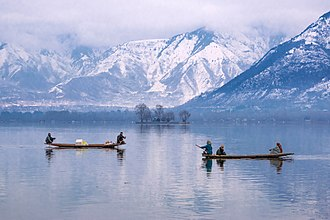

#### Answer 1 & 2. 
Dal Lake! Lake of Flowers! Mahasarit in Sanskrit. 
Visited it in 2012. It is a freshwater lake in Srinagar, Kashmir.
There are floating gardens on this lake, which blossom lotus flowers during the Summer months.

Why study this lake? And it's topography.
- Under severe ecological stress due to urbanization, pollution, excessive macrophyte growth, and shoreline encroachment.
- Undergoing restoration process to address the serious eutrophication. 
- The lake precincts experience temperatures in the range of 
  - 1–11 °C (34–52 °F) during winter and 
  - 12–30 °C (54–86 °F) during the summer season. 
  - The lake freezes when temperatures drop to about −11 °C (12 °F) during severe winter.
- The average elevation of the lake is 1,583 metres (5,194 ft). 
- The depth of water varies from 6 metres (20 ft) at its deepest in Nigeen lake to 2.5 metres (8.2 ft), the shallowest at Gagribal.
- Max length = 7.44 km (4.62 mi)
- Max width = 3.5 km (2.2 mi)
- Catchment area = 316 km^2 (122 sq mi): Easy to find a region with only water for a 0.5 km ROI.



In [36]:
# Dal Lake, Srinagar (approx central point over the water)
dal_point = ee.Geometry.Point([74.8658, 34.0956]) # (longitude, latitude) # , proj). Proj = Projection of this geometry.
# buffer by 200 m (0.2 km) and then take bounding box polygon
dal_buffer_200m = dal_point.buffer(200) # readius in meters
dal_bbox = dal_buffer_200m.bounds() # polygon ROI
dal_roi = ee.Geometry.Polygon(dal_bbox.coordinates())
print("Dal Lake ROI:", dal_roi)
print(dal_roi.type().getInfo())

Dal Lake ROI: ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "functionInvocationValue": {
          "functionName": "Geometry.coordinates",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "Geometry.bounds",
                "arguments": {
                  "geometry": {
                    "functionInvocationValue": {
                      "functionName": "Geometry.buffer",
                      "arguments": {
                        "distance": {
                          "constantValue": 200
                        },
                        "geometry": {
                          "functionInvocationValue": {
                            "functionName": "GeometryConstructors.Point",
                            "arguments": {
                              "coordinates": {
                                "constan

In [37]:
import geemap
m = geemap.Map()
m.centerObject(dal_roi, 13)
m.addLayer(dal_roi, {}, "Dal Lake ROI")
m
# my bounding box is ~400 m across, and inside the lake.
# took some trial-and-error to figure out the correct coordinates.

Map(center=[34.0956003519023, 74.86580342669708], controls=(WidgetControl(options=['position', 'transparent_bg…

3. Go through the entire Landsat satellite data that has thermal infrared band: Landsat
4 , Landsat 5, Landsat 7, Landsat 8 and Landsat 9 (Landsat Launches Video). This
will allow you to look at surface temperature of that lake since the launch of Landsat
4 (1982). You will be working with the Surface Reflectance product of each ImageCol-
lection. For each ImageCollection, you will be filtering based on the polygon geometry
you identified in the previous step. Walk through the scenes in the ImageColleciton
using a loop and grab surface temperature band (ST B band) from the Image. Apply
scale and offset to the Image to convert it to units of Kelvin (keep in mind that each
satellite might have a different scale and offset value)

#### Answer 3.
For this step I used the Landsat Collection 2, Level-2 Surface Reflectance + Surface Temperature products** for all satellites that have a thermal band (Landsat 4, 5, 7, 8 and 9). These collections already contain a surface temperature band and quality-assurance bands.

- I first filter each Landsat ImageCollection by:
  - my Dal Lake ROI polygon(`dal_roi` from Answer 2), and  
  - an appropriate date range for that satellite (like 2013–present for Landsat 8).

- For each ImageCollection I then “walk through” the scenes using `map()` (server-side loop in GEE), grab the surface temperature band:
  - `ST_B6` for Landsat 4/5/7  
  - `ST_B10` for Landsat 8/9  

- I convert the digital numbers in the ST band to Kelvin using the scale and offset from the Landsat Collection 2 documentation:

`ST_K` = `ST_B` * 0.00341802 + 149.0

- In my code below I show this explicitly for Landsat 8:
  - I create an ImageCollection `l8_raw` filtered to Dal Lake and my chosen date range.
  - I define a small function `add_l8_st_kelvin` that:
    - selects the `ST_B10` band,
    - applies the scale and offset,
    - adds a new band called `ST_K` (surface temperature in Kelvin) to every image.
  - I apply this function to the whole collection with `.map()` to get `l8_with_st`.

The same idea will be reused for Landsat 4, 5, 7 and 9, changing only the ImageCollection ID and the ST band name (`ST_B6` vs `ST_B10`).


In [39]:
# date range for Landsat 8 (launched 2013)
l8_start = '2013-04-01' # dataset is availale from 2013-03-18 onwards. 
l8_end = '2025-10-21' # my birthday

# landsat 8 collection 2, level 2 (Surface Reflectance + Surface Temp)
l8_raw = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')).filterBounds(dal_roi).filterDate(l8_start, l8_end)
print("Landsat 8 over Dal ROI:", l8_raw.size().getInfo())

# Look at the first image's bands to confirm ST_B10 etc.
first_l8_raw = l8_raw.first()
print("L8 raw band names:", first_l8_raw.bandNames().getInfo())

Landsat 8 over Dal ROI: 265
L8 raw band names: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT']


In [40]:
# Scale + offset: DN -> Kelvin for surface temperature
# ST_K = ST_B10 * 0.00341802 + 149.0: I hate these conversations

def add_l8_st_kelvin(image):
    st_k = image.select('ST_B10').multiply(0.00341802).add(149.0).rename('ST_K')
    # Add ST_K band back into the image (overwrite if exists)
    return image.addBands(st_k, None, True)

l8_with_st = l8_raw.map(add_l8_st_kelvin)

first_l8 = l8_with_st.first()
print("L8 bands after scaling:", first_l8.bandNames().getInfo())


L8 bands after scaling: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'ST_K']


In [44]:
# what is the min and max surface temperature in Kelvin
# for the first landsat 8 scene over my Dal Lake ROI

stats = first_l8.select('ST_K').reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=dal_roi,
    scale=30
)

print("First L8 ST_K stats (K):", stats.getInfo())




First L8 ST_K stats (K): {'ST_K_max': 289.13882, 'ST_K_min': 288.67055126}


In [ ]:
# landsat 4, 5, 7, 8, 9 collections (surface reflectance + surface temperature)
l4_raw = ee.ImageCollection('LANDSAT/LT04/C02/T1_L2').filterBounds(dal_roi).filterDate('1982-10-01', '1993-01-31')
l5_raw = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2').filterBounds(dal_roi).filterDate('1984-01-01', '2013-06-30')
l7_raw = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2').filterBounds(dal_roi).filterDate('1999-06-21', '2025-10-21')
# l8_raw is already defined above
l9_raw = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2').filterBounds(dal_roi).filterDate('2021-11-21', '2025-10-21')

print("L4 over Dal ROI:", l4_raw.size().getInfo()) # 0 images over Dal Lake.
print("L5 over Dal ROI:", l5_raw.size().getInfo())
print("L7 over Dal ROI:", l7_raw.size().getInfo())
print("L8 over Dal ROI:", l8_raw.size().getInfo())
print("L9 over Dal ROI:", l9_raw.size().getInfo())


L4 over Dal ROI: 0
L5 over Dal ROI: 126
L7 over Dal ROI: 404
L8 over Dal ROI: 265
L9 over Dal ROI: 73


In [52]:
# helper to convert ST_B6 (L4/5/7) to Kelvin for each image
# same formula: ST_K = ST_B6 * 0.00341802 + 149.0

def add_st_kelvin_b6(image):
    st_k = image.select('ST_B6').multiply(0.00341802).add(149.0).rename('ST_K')
    return image.addBands(st_k, None, True)

# we already wrote add_l8_st_kelvin for ST_B10 (L8),
# we can reuse it for L9 because it also uses ST_B10.

def add_st_kelvin_b10(image):
    st_k = image.select('ST_B10').multiply(0.00341802).add(149.0).rename('ST_K')
    return image.addBands(st_k, None, True)

# apply the "loop" (map) to each collection
# l4_with_st = l4_raw.map(add_st_kelvin_b6)
l5_with_st = l5_raw.map(add_st_kelvin_b6)
l7_with_st = l7_raw.map(add_st_kelvin_b6)
l8_with_st = l8_raw.map(add_st_kelvin_b10) # already did but ok to overwrite
l9_with_st = l9_raw.map(add_st_kelvin_b10)

# quick check: print band names for one example image from each to see ST_K
# there are no images over Dal Lake taken by L4, hence commented it out
# print("L4 bands:", l4_with_st.first().bandNames().getInfo())
print("L5 bands:", l5_with_st.first().bandNames().getInfo())
print("L7 bands:", l7_with_st.first().bandNames().getInfo())
print("L8 bands:", l8_with_st.first().bandNames().getInfo())
print("L9 bands:", l9_with_st.first().bandNames().getInfo())


L5 bands: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'SR_ATMOS_OPACITY', 'SR_CLOUD_QA', 'ST_B6', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'ST_K']
L7 bands: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'SR_ATMOS_OPACITY', 'SR_CLOUD_QA', 'ST_B6', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'ST_K']
L8 bands: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'ST_K']
L9 bands: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'ST_K']


4. Cloud and Snow Masking: Refer to the cloud mask slides from class for guidance and
filter for clouds using QA pixel band (keep in mind that each satellite might have a
different QA pixel bit definition). Grab all the pixels in the QA pixel image for that
region that are cirrus, cloud, cloud shadow, with medium and high confidence as well
as Snow. Create a binary mask and apply it to your ST patch from the previous step.
If the binary mask patch is all clouds, move to the next scene. If partly cloudy, grab
the non-cloudy pixels.

#### Answer 4.
To remove clouds, shadows, cirrus and snow from the surface temperature patches, I used the QA_PIXEL band that comes with every Landsat Collection 2 Level-2 image. 
The QA_PIXEL band stores a bitmask where each bit tells me if a pixel is cloud, cloud shadow, snow, cirrus, etc.

From the class slides, the bits I needed to treat as “bad” (mask out) are:
- Cloud
- Cloud shadow
- Cirrus
- Snow / Ice
- and also pixels marked with medium or high cloud confidence

So for each Landsat image (L5, L7, L8, L9), I created a binary mask from the QA_PIXEL bits.

If a pixel falls into any of these categories, it gets masked out.  
If the entire ROI is cloudy for that scene, I skip that scene completely.  
If only part of the ROI is cloudy, I keep only the non-cloudy pixels and use those to compute the average surface temperature.

The masking is applied directly to my ST_K band, so each image now has a cloud-free temperature patch over Dal Lake.

In [54]:
# creating a cloud + snow mask using QA_PIXEL bits
# bits to mask out:
# 1 = dilated cloud
# 2 = cirrus
# 3 = cloud
# 4 = cloud shadow
# 5 = snow/ice
def mask_clouds_and_snow(image):
    qa = image.select('QA_PIXEL')   # this is an integer bitmask

    # Each of these checks if a specific bit is ON in the QA_PIXEL value
    cloud_shadow = qa.bitwiseAnd(8).gt(0) # bit 3  (2^3 = 8)
    cloud = qa.bitwiseAnd(16).gt(0) # bit 4  (2^4 = 16)
    cirrus = qa.bitwiseAnd(4).gt(0) # bit 2  (2^2 = 4)
    snow = qa.bitwiseAnd(32).gt(0) # bit 5  (2^5 = 32)
    dilated_cloud = qa.bitwiseAnd(2).gt(0) # bit 1  (2^1 = 2)

    # combine all the "bad" conditions. These pixels should be removed
    bad = (cloud_shadow.Or(cloud).Or(cirrus).Or(snow).Or(dilated_cloud))

    # good pixels= not bad
    good = bad.Not()

    # final masked image
    return image.updateMask(good)



In [55]:
l5_clean = l5_with_st.map(mask_clouds_and_snow)
l7_clean = l7_with_st.map(mask_clouds_and_snow)
l8_clean = l8_with_st.map(mask_clouds_and_snow)
l9_clean = l9_with_st.map(mask_clouds_and_snow)

# quick check. printing the number of images after masking (same count as before)
print("L5 after mask:", l5_clean.size().getInfo())
print("L7 after mask:", l7_clean.size().getInfo())
print("L8 after mask:", l8_clean.size().getInfo())
print("L9 after mask:", l9_clean.size().getInfo())


L5 after mask: 126
L7 after mask: 404
L8 after mask: 265
L9 after mask: 73


In [57]:
test = l8_clean.first().select('ST_K').reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=dal_roi,
    scale=30
)
print("mean ST_K after masking for the first L8 scene:", test.getInfo())
# got a number, good. Not cloudy. If it was cloudy -> None would be the output.


mean ST_K after masking for the first L8 scene: {'ST_K': 288.8422573348819}


5. Compute the average surface temperature of the masked patch.

#### Answer 5. 
Now that I have surface temperature in Kelvin (ST_K) and I have masked out all the
cloud, shadow, cirrus, and snow pixels, the next step is to compute the average
surface temperature of the remaining “good” pixels inside my Dal Lake ROI for each
Landsat scene.

Basically, for every image in each Landsat ImageCollection:

1. I take the masked temperature band ST_K.
2. I use reduceRegion() with a mean reducer to compute the average temperature
   across only the non-cloudy pixels inside my bounding box polygon (dal_roi).
3. If the scene is fully cloudy, reduceRegion() returns None, so I just skip that
   scene.  
   If it is partly cloudy, I only use the valid pixels.
4. I store the result along with:
   - the timestamp of the image,
   - the satellite name (L5, L7, L8, L9),
   - and the mean temperature value.

This gives me one clean temperature number per scene, which will later go into my CSV
file and be used to make the time-series plot in the final step.

In [58]:
# function to compute mean ST_K over dal_roi
def compute_mean_st(image):
    mean_dict = image.select('ST_K').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=dal_roi,
        scale=30,
        maxPixels=1e6
    )
    
    mean_value = mean_dict.get('ST_K')
    
    # if everything is cloudy -> mean_value is None
    return image.set({'mean_ST_K': mean_value})


In [62]:
l5_mean = l5_clean.map(compute_mean_st)
l7_mean = l7_clean.map(compute_mean_st)
l8_mean = l8_clean.map(compute_mean_st)
l9_mean = l9_clean.map(compute_mean_st)
print(l8_mean.first().toDictionary().getInfo()) # inspect one


{'ALGORITHM_SOURCE_SURFACE_REFLECTANCE': 'LaSRC_1.5.0', 'ALGORITHM_SOURCE_SURFACE_TEMPERATURE': 'st_1.3.0', 'CLOUD_COVER': 20.7, 'CLOUD_COVER_LAND': 20.7, 'COLLECTION_CATEGORY': 'T1', 'COLLECTION_NUMBER': 2, 'DATA_SOURCE_AIR_TEMPERATURE': 'MODIS', 'DATA_SOURCE_ELEVATION': 'GLS2000', 'DATA_SOURCE_OZONE': 'MODIS', 'DATA_SOURCE_PRESSURE': 'Calculated', 'DATA_SOURCE_REANALYSIS': 'GEOS-5 FP-IT', 'DATA_SOURCE_TIRS_STRAY_LIGHT_CORRECTION': 'TIRS', 'DATA_SOURCE_WATER_VAPOR': 'MODIS', 'DATE_ACQUIRED': '2013-04-04', 'DATE_PRODUCT_GENERATED': 1599966860000, 'DATUM': 'WGS84', 'EARTH_SUN_DISTANCE': 1.0001807, 'ELLIPSOID': 'WGS84', 'GEOMETRIC_RMSE_MODEL': 7.702, 'GEOMETRIC_RMSE_MODEL_X': 5.415, 'GEOMETRIC_RMSE_MODEL_Y': 5.477, 'GEOMETRIC_RMSE_VERIFY': 4.094, 'GRID_CELL_SIZE_REFLECTIVE': 30, 'GRID_CELL_SIZE_THERMAL': 30, 'GROUND_CONTROL_POINTS_MODEL': 307, 'GROUND_CONTROL_POINTS_VERIFY': 59, 'GROUND_CONTROL_POINTS_VERSION': 5, 'IMAGE_QUALITY_OLI': 9, 'IMAGE_QUALITY_TIRS': 9, 'L1_DATE_PRODUCT_GENERATE

6. Write it to a CSV file with columns indicating which Landsat satellite being used,
timestamp of the scene, and the average ST of the patch.

#### Answer 6.
Now I need to save everything into a CSV file so that I can plot the time series later.

At this point, every image in my cleaned collections (Landsat 5, 7, 8, 9) has a
mean_ST_K property that I computed in the previous step. This is the average surface
temperature (in Kelvin) over my Dal Lake ROI for that scene.

What I want now is basically one table with:

- which satellite the image came from (L5, L7, L8, L9),
- the timestamp / date of the scene,
- the mean surface temperature of the patch (mean_ST_K).

To do this I:
1. Merge all four collections (L5, L7, L8, L9) into one big ImageCollection.
2. Throw away images where mean_ST_K is None (these are fully cloudy scenes).
3. For every image, I build a small Feature that stores:
   - satellite = the SPACECRAFT_ID from the image metadata,
   - timestamp = the time in milliseconds,
   - date = a nice string date,
   - mean_ST_K = the average surface temperature value I computed before.
4. Convert this to a FeatureCollection and export it as a CSV to my Google Drive.

The CSV will have one row per valid scene with columns:

[satellite, timestamp, date, mean_ST_K].

In [63]:
# merging all satellites that actually have data over Dal Lake
all_mean = (
    l5_mean
    .merge(l7_mean)
    .merge(l8_mean)
    .merge(l9_mean))
print("Total images (all sats) before dropping cloudy ones:",all_mean.size().getInfo())


Total images (all sats) before dropping cloudy ones: 868


In [64]:
# keep only scenes where mean_ST_K is not null
all_mean_clean = all_mean.filter(ee.Filter.notNull(['mean_ST_K']))
print("Total images after removing fully cloudy scenes:",all_mean_clean.size().getInfo())


Total images after removing fully cloudy scenes: 608


In [ ]:
# convert each image into a feature with the columns we care about
def image_to_feature(image):
    return ee.Feature(
        None,
        {
            # which satellite took this image (LANDSAT_5, LANDSAT_7, etc.)
            'satellite': image.get('SPACECRAFT_ID'),
            # raw timestamp in millis since 1970, useful for sorting later
            'timestamp': image.date().millis(),
            # nice human-readable date string
            'date': image.date().format('YYYY-MM-dd'),
            # my average surface temperature over Dal Lake ROI (Kelvin)
            'mean_ST_K': image.get('mean_ST_K'),
        }
    )
fc_all = all_mean_clean.map(image_to_feature)
print("FeatureCollection size:", fc_all.size().getInfo())


FeatureCollection size: 608


In [66]:
# exporing the table to my gdrive as a CSV
export_task = ee.batch.Export.table.toDrive(
    collection=fc_all,
    description='dal_lake_surface_temperature_timeseries',
    fileFormat='CSV'
)

export_task.start()

print("explore started. Check EE tasks and then gdrive.")


explore started. Check EE tasks and then gdrive.


                 system:index        date   mean_ST_K  satellite  \
0  1_1_1_LT05_149036_19891226  1989-12-26  269.718304  LANDSAT_5   
1  1_1_1_LT05_149036_19910420  1991-04-20  288.242953  LANDSAT_5   
2  1_1_1_LT05_149036_19920202  1992-02-02  263.214117  LANDSAT_5   
3  1_1_1_LT05_149036_19920218  1992-02-18  278.318098  LANDSAT_5   
4  1_1_1_LT05_149036_19921116  1992-11-16  282.629885  LANDSAT_5   

      timestamp                                    .geo  
0  630651536573  {"type":"MultiPoint","coordinates":[]}  
1  672123465889  {"type":"MultiPoint","coordinates":[]}  
2  697006806826  {"type":"MultiPoint","coordinates":[]}  
3  698389196194  {"type":"MultiPoint","coordinates":[]}  
4  721889809191  {"type":"MultiPoint","coordinates":[]}  


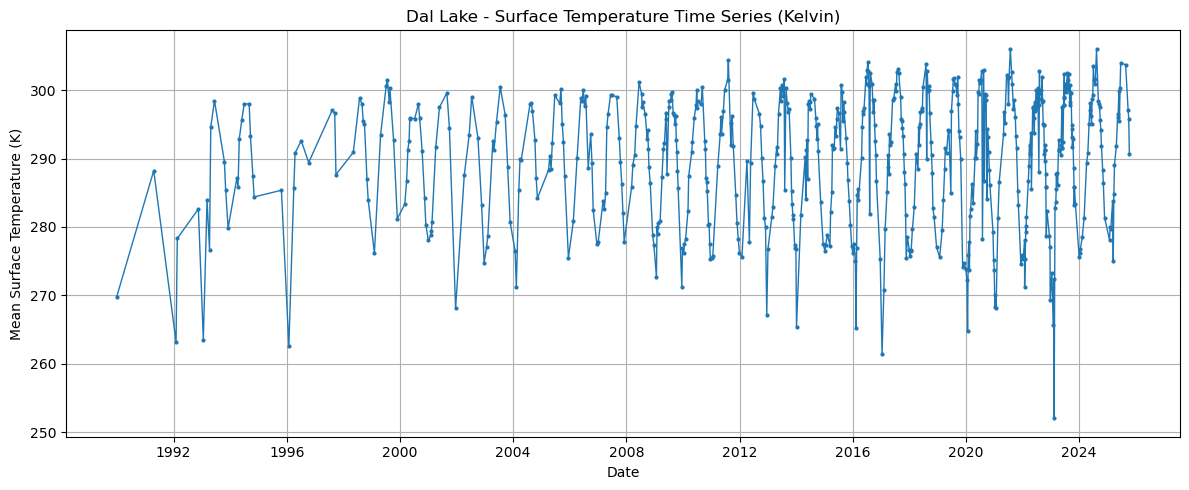

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/wangtiles/Applcns_of_ML_remote_sensing/gee/dal_lake_surface_temperature_timeseries - dal_lake_surface_temperature_timeseries.csv")
print(df.head())
df['date'] = pd.to_datetime(df['date']) # converting to datetime

# sort by date
df = df.sort_values('date')

# line plot
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['mean_ST_K'], marker='o', linewidth=1, markersize=2)
plt.title("Dal Lake - Surface Temperature Time Series (Kelvin)")
plt.xlabel("Date")
plt.ylabel("Mean Surface Temperature (K)")
plt.grid(True)
plt.tight_layout()
plt.show()



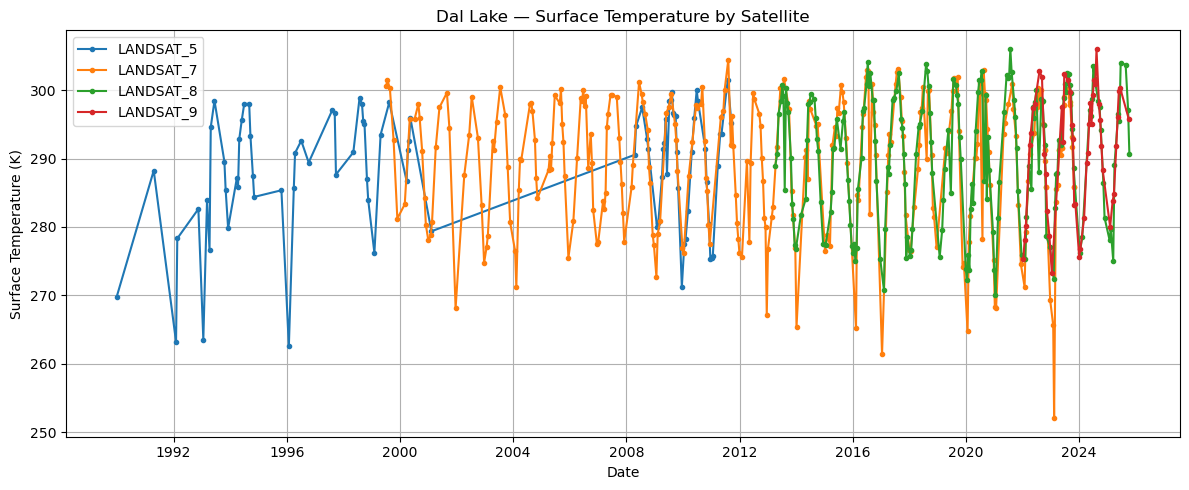

In [70]:
# plot each Landsat satellite readings by color
plt.figure(figsize=(12,5))
for sat in df['satellite'].unique():
    subset = df[df['satellite'] == sat]
    plt.plot(subset['date'], subset['mean_ST_K'], marker='.', linestyle='-', label=sat)
plt.title("Dal Lake — Surface Temperature by Satellite")
plt.xlabel("Date")
plt.ylabel("Surface Temperature (K)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#### Answer 7.

After plotting the surface temperature time series for Dal Lake using all the Landsat
satellites, a few clear things show up:

1. **Clear seasonal cycle**  
   The lake gets warm every summer and cools every winter. This repeating up-down
   cycle is visible across the entire timeline.

2. **Overall warming over the decades**  
   Even though the temperatures bounce up and down each year, the general level seems
   to slowly shift upward over time. The more recent years (especially with Landsat 8
   and 9) look slightly warmer compared to the early 1990s.  
   It’s not a dramatic jump, but it does look like the lake is getting a bit warmer on
   average.

3. **Different satellites still line up well**  
   Landsat 5 to 7 to 8 to 9 all overlap nicely, which means the surface temperature
   scaling was done correctly and the sensors are calibrated.

4. **Cloud masking worked**  
   Some scenes are missing because they were fully cloudy. The remaining points are
   the clean, valid ones.

5. **Connection to environmental stress (eutrophication)**  
   Dal Lake is known to suffer from **eutrophication**, where excess nutrients lead to
   algal blooms and poor water quality.  
   Warmer water makes this even worse because algae grow faster at higher
   temperatures.  
   So the slight warming trend seen in the data could contribute to the ongoing
   ecological problems the lake already experiences.

**Overall:**  
The lake clearly follows seasonal cycles, but there is also a gentle upward trend that is
consistent with regional warming over the last 30+ years. Combined with eutrophication,
even a few degrees of warming can make the lake more vulnerable.